<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch3-soak-decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformer-lens


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.7 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=55b3cff2a1bee1fecc3e120c4359c64578555b362596b89a5a7fc38821c89dfb
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


In [ ]:
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("pythia-70m")

# the matched pair from Chapter 2 — identical except one word
pair_pos = "The meal at the restaurant was absolutely wonderful and the evening felt complete."
pair_neg = "The meal at the restaurant was absolutely terrible and the evening felt complete."

tp = model.to_tokens(pair_pos); tn = model.to_tokens(pair_neg)
_, cp = model.run_with_cache(tp); _, cn = model.run_with_cache(tn)

# matched-pair sets for building the per-layer sentiment axis
pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]

def resid_at(prompts, layer):
    vecs = []
    for p in prompts:
        _, c = model.run_with_cache(model.to_tokens(p))
        vecs.append(c["resid_post", layer][0].mean(dim=0))
    return torch.stack(vecs)

# sanity check the flip position before trusting [8:13]
toks = model.to_str_tokens(pair_pos)
for i, t in enumerate(toks): print(i, repr(t))


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model pythia-70m into HookedTransformer
0 'The'
1 ' meal'
2 ' at'
3 ' the'
4 ' restaurant'
5 ' was'
6 ' absolutely'
7 ' wonderful'
8 ' and'
9 ' the'
10 ' evening'
11 ' felt'
12 ' complete'
13 '.'


In [ ]:
torch.manual_seed(3)
rand_axis = torch.randn(512); rand_axis = rand_axis / rand_axis.norm()

print(f"{'layer':>5} {'on-axis':>8} {'off-axis':>9} {'ratio':>7} {'on-random':>10}")
for L in range(6):
    dvec = cp["resid_post", L][0] - cn["resid_post", L][0]

    pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
    axis = pa.mean(0) - na.mean(0); axis = axis / axis.norm()

    on_axis  = (dvec @ axis).abs()
    off_axis = (dvec - (dvec @ axis)[:, None] * axis[None, :]).norm(dim=-1)
    on_rand  = (dvec @ rand_axis).abs()

    s_on, s_off, s_rnd = on_axis[9:14].mean().item(), off_axis[9:14].mean().item(), on_rand[9:14].mean().item()
    print(f"{L:>5} {s_on:>8.3f} {s_off:>9.3f} {s_on/s_off:>7.3f} {s_rnd:>10.3f}")


layer  on-axis  off-axis   ratio  on-random
    0    0.068     0.443   0.153      0.023
    1    0.372     0.965   0.385      0.043
    2    0.788     2.050   0.384      0.110
    3    0.936     1.795   0.521      0.069
    4    1.512     2.593   0.583      0.069
    5    2.865     4.486   0.639      0.314


In [ ]:
import torch

# ten FRESH matched pairs — not in the axis-building set
test_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clean.",
     "The report on the findings read hopeless and the figures looked clean."),
]

def flip_and_window(tp, tn):
    """Find the flipped position; return it and the downstream window. None if pair is unusable."""
    if tp.shape != tn.shape:
        return None, None                       # words tokenized to different lengths — skip
    diff = (tp[0] != tn[0]).nonzero().flatten()
    if len(diff) != 1:
        return None, None                       # more than one token differs — skip
    f = diff.item()
    return f, (f + 1, tp.shape[1])              # everything after the flip

results = {L: [] for L in range(6)}             # ratio per layer, per pair
rand_on = {L: [] for L in range(6)}

torch.manual_seed(3)
rand_axis = torch.randn(512); rand_axis = rand_axis / rand_axis.norm()

# axis per layer, built ONCE from the original matched sets (held out from test pairs)
axes = {}
for L in range(6):
    pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
    a = pa.mean(0) - na.mean(0); axes[L] = a / a.norm()

used = 0
for s_pos, s_neg in test_pairs:
    tp, tn = model.to_tokens(s_pos), model.to_tokens(s_neg)
    f, win = flip_and_window(tp, tn)
    if f is None:
        print(f"SKIPPED (tokenization mismatch): {s_pos[:40]}...")
        continue
    used += 1
    _, cp2 = model.run_with_cache(tp); _, cn2 = model.run_with_cache(tn)
    for L in range(6):
        dvec = cp2["resid_post", L][0] - cn2["resid_post", L][0]
        axis = axes[L]
        on  = (dvec @ axis).abs()[win[0]:win[1]].mean().item()
        off = (dvec - (dvec @ axis)[:, None] * axis[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
        rnd = (dvec @ rand_axis).abs()[win[0]:win[1]].mean().item()
        results[L].append(on / off)
        rand_on[L].append(rnd / off)

print(f"\npairs used: {used}/10")
print(f"{'layer':>5} {'ratio mean':>11} {'min':>7} {'max':>7} {'rand ratio':>11}")
for L in range(6):
    r = torch.tensor(results[L]); rr = torch.tensor(rand_on[L])
    print(f"{L:>5} {r.mean():>11.3f} {r.min():>7.3f} {r.max():>7.3f} {rr.mean():>11.3f}")


SKIPPED (tokenization mismatch): The bread from the bakery smelled amazin...

pairs used: 9/10
layer  ratio mean     min     max  rand ratio
    0       0.130   0.043   0.261       0.041
    1       0.242   0.158   0.349       0.036
    2       0.241   0.094   0.362       0.032
    3       0.341   0.222   0.490       0.032
    4       0.402   0.178   0.491       0.027
    5       0.379   0.140   0.484       0.038


flip-caused downstream change concentrates onto the sentiment direction as depth increases — from ~13% of the off-axis magnitude at layer 0 to ~40% by layers 3–5, an order of magnitude above a random direction — across 9 held-out matched pairs. The concentration saturates rather than compounding indefinitely, and varies substantially by sentence.

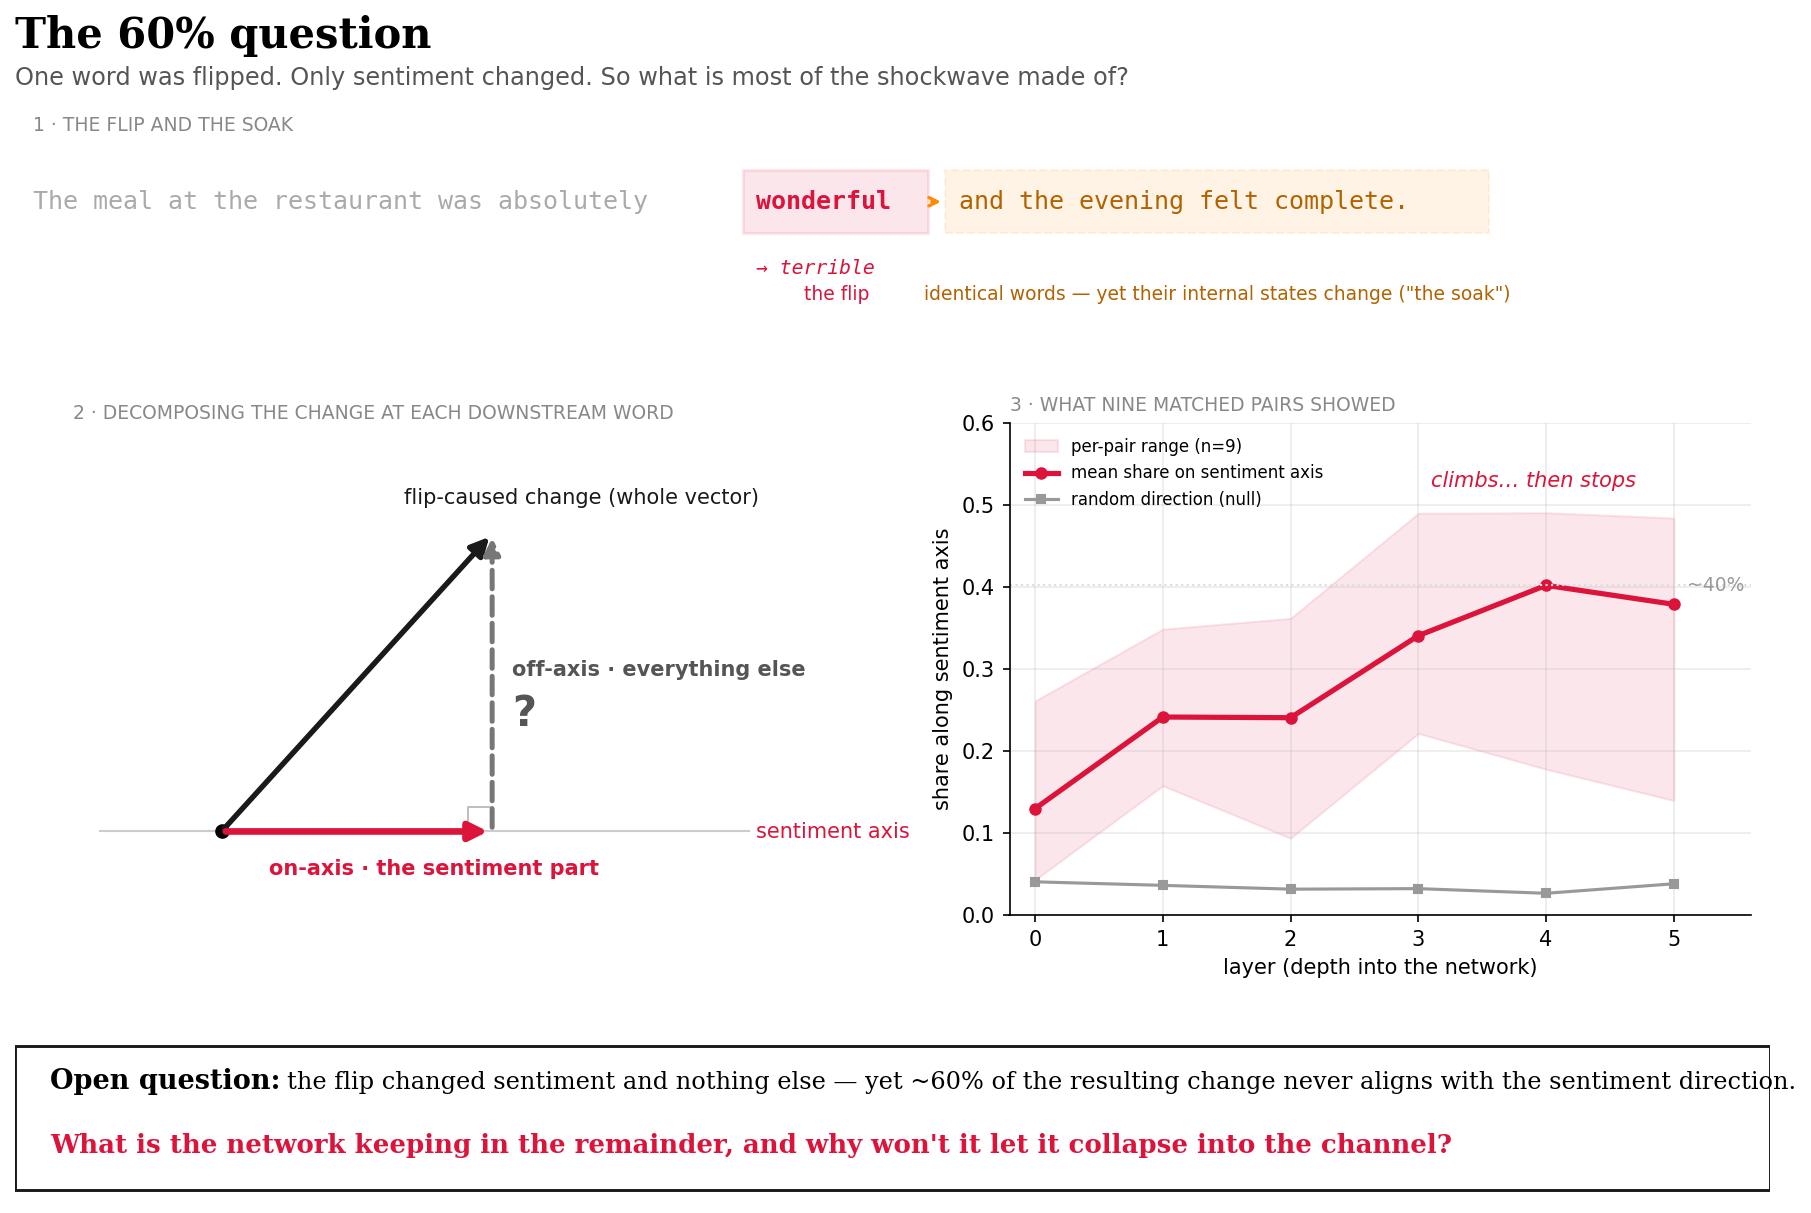

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- recompute the n=9 data live ----------
def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    diff = (tp[0] != tn[0]).nonzero().flatten()
    if len(diff) != 1: return None, None
    f = diff.item()
    return f, (f + 1, tp.shape[1])

torch.manual_seed(3)
rand_axis = torch.randn(512); rand_axis = rand_axis / rand_axis.norm()

axes_by_layer = {}
for L in range(6):
    pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
    a = pa.mean(0) - na.mean(0); axes_by_layer[L] = a / a.norm()

ratios = {L: [] for L in range(6)}
rands  = {L: [] for L in range(6)}
for s_pos, s_neg in test_pairs:
    tp, tn = model.to_tokens(s_pos), model.to_tokens(s_neg)
    f, win = flip_and_window(tp, tn)
    if f is None: continue
    _, cp2 = model.run_with_cache(tp); _, cn2 = model.run_with_cache(tn)
    for L in range(6):
        dvec = cp2["resid_post", L][0] - cn2["resid_post", L][0]
        axis = axes_by_layer[L]
        on  = (dvec @ axis).abs()[win[0]:win[1]].mean().item()
        off = (dvec - (dvec @ axis)[:, None] * axis[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
        rnd = (dvec @ rand_axis).abs()[win[0]:win[1]].mean().item()
        ratios[L].append(on / off); rands[L].append(rnd / off)

layers = np.arange(6)
ratio = np.array([np.mean(ratios[L]) for L in layers])
rmin  = np.array([np.min(ratios[L])  for L in layers])
rmax  = np.array([np.max(ratios[L])  for L in layers])
rand  = np.array([np.mean(rands[L])  for L in layers])
n_pairs = len(ratios[0])

# ---------- draw ----------
fig = plt.figure(figsize=(13, 8.2), dpi=150)
fig.patch.set_facecolor('white')

ax_top = fig.add_axes([0.05, 0.76, 0.90, 0.16]); ax_top.axis('off')
ax_vec = fig.add_axes([0.06, 0.24, 0.40, 0.44])
ax_cur = fig.add_axes([0.56, 0.26, 0.38, 0.40])
ax_q   = fig.add_axes([0.05, 0.03, 0.90, 0.13]); ax_q.axis('off')

fig.text(0.05, 0.965, "The 60% question", fontsize=20, fontweight='bold', family='serif')
fig.text(0.05, 0.935, "One word was flipped. Only sentiment changed. So what is most of the shockwave made of?",
         fontsize=11.5, color='#555555')

# Panel 1: sentence
ax_top.set_xlim(0, 100); ax_top.set_ylim(0, 10)
ax_top.text(1, 8.6, "1 · THE FLIP AND THE SOAK", fontsize=9, color='#888888', family='sans-serif')
ax_top.text(1, 5, "The meal at the restaurant was absolutely", fontsize=12, family='monospace', color='#aaaaaa', va='center')
ax_top.add_patch(Rectangle((41.5, 3.4), 10.5, 3.2, facecolor='#dc143c', alpha=0.10, edgecolor='#dc143c', lw=1.4))
ax_top.text(42.2, 5, "wonderful", fontsize=12, family='monospace', color='#dc143c', fontweight='bold', va='center')
ax_top.text(42.2, 1.6, "→ terrible", fontsize=9.5, family='monospace', color='#dc143c', style='italic', va='center')
ax_top.text(46.8, 0.0, "the flip", fontsize=9, color='#dc143c', ha='center')
ax_top.add_patch(Rectangle((53, 3.4), 31, 3.2, facecolor='#ff8c00', alpha=0.10, edgecolor='#ff8c00', lw=1.0, linestyle='--'))
ax_top.text(53.8, 5, "and the evening felt complete.", fontsize=12, family='monospace', color='#b36200', va='center')
ax_top.text(68.5, 0.0, 'identical words — yet their internal states change ("the soak")', fontsize=9, color='#b36200', ha='center')
ax_top.annotate('', xy=(53, 5), xytext=(52, 5), arrowprops=dict(arrowstyle='->', color='#ff8c00', lw=1.6))

# Panel 2: vector decomposition
ax_vec.set_xlim(-1.2, 4.2); ax_vec.set_ylim(-0.8, 3.2)
ax_vec.set_aspect('equal'); ax_vec.axis('off')
ax_vec.text(-1.1, 3.05, "2 · DECOMPOSING THE CHANGE AT EACH DOWNSTREAM WORD", fontsize=9, color='#888888', family='sans-serif')
ax_vec.plot([-0.9, 3.9], [0, 0], color='#cccccc', lw=1)
ax_vec.text(3.95, 0, "sentiment axis", fontsize=10, color='#dc143c', va='center')
ax_vec.annotate('', xy=(2.0, 2.2), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='#1a1a1a', lw=2.6, mutation_scale=18))
ax_vec.text(1.35, 2.42, "flip-caused change (whole vector)", fontsize=10, color='#1a1a1a')
ax_vec.annotate('', xy=(2.0, 0), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='#dc143c', lw=3.2, mutation_scale=18))
ax_vec.text(0.35, -0.32, "on-axis · the sentiment part", fontsize=10, color='#dc143c', fontweight='bold')
ax_vec.annotate('', xy=(2.0, 2.2), xytext=(2.0, 0), arrowprops=dict(arrowstyle='-|>', color='#777777', lw=2.4, linestyle='--', mutation_scale=16))
ax_vec.text(2.15, 1.15, "off-axis · everything else", fontsize=10, color='#555555', fontweight='bold')
ax_vec.text(2.15, 0.78, "?", fontsize=20, color='#555555', fontweight='bold')
ax_vec.plot([2.0, 1.82, 1.82], [0.18, 0.18, 0], color='#bbbbbb', lw=0.9)
ax_vec.plot(0, 0, 'ko', ms=6)

# Panel 3: the curve (live data)
ax_cur.set_title(f"3 · WHAT {['ZERO','ONE','TWO','THREE','FOUR','FIVE','SIX','SEVEN','EIGHT','NINE','TEN'][n_pairs]} MATCHED PAIRS SHOWED",
                 fontsize=9, color='#888888', loc='left', family='sans-serif')
ax_cur.fill_between(layers, rmin, rmax, color='#dc143c', alpha=0.10, label=f'per-pair range (n={n_pairs})')
ax_cur.plot(layers, ratio, 'o-', color='#dc143c', lw=2.5, ms=5, label='mean share on sentiment axis')
ax_cur.plot(layers, rand, 's-', color='#999999', lw=1.5, ms=4, label='random direction (null)')
peak = ratio.max()
ax_cur.axhline(peak, color='#dddddd', lw=1, ls=':')
ax_cur.text(5.1, peak, f"~{peak*100:.0f}%", fontsize=9, color='#999999', va='center')
ax_cur.text(3.9, min(peak + 0.12, 0.56), "climbs… then stops", fontsize=10, color='#dc143c', style='italic', ha='center')
ax_cur.set_xlabel("layer (depth into the network)", fontsize=10)
ax_cur.set_ylabel("share along sentiment axis", fontsize=10)
ax_cur.set_xticks(layers); ax_cur.set_ylim(0, 0.60); ax_cur.set_xlim(-0.2, 5.6)
ax_cur.legend(fontsize=8, loc='upper left', frameon=False)
ax_cur.spines[['top','right']].set_visible(False)
ax_cur.grid(alpha=0.25)

# Question band
ax_q.set_xlim(0,1); ax_q.set_ylim(0,1)
ax_q.add_patch(Rectangle((0.0, 0.05), 1.0, 0.9, fill=False, edgecolor='#1a1a1a', lw=1.4))
ax_q.text(0.02, 0.68, "Open question:", fontsize=13, fontweight='bold', family='serif')
ax_q.text(0.155, 0.68, f"the flip changed sentiment and nothing else — yet ~{(1-peak)*100:.0f}% of the resulting change never aligns with the sentiment direction.",
          fontsize=11.5, family='serif')
ax_q.text(0.02, 0.28, "What is the network keeping in the remainder, and why won't it let it collapse into the channel?",
          fontsize=12.5, color='#dc143c', fontweight='bold', family='serif')

plt.savefig("sixty_percent_question.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


Hypothesis: the answer is in predictability law itself. The network was never trained to represent sentiment — it was trained to predict. The flip doesn’t just change a feature; it re-weights the probability of everything downstream. The 40% is the shadow that re-weighting casts on the one direction we have a filter for; the 60% may be the rest of the predictive adjustment — consequence, not noise. Two tests would tell: whether the residue decodes into coherent vocabulary shifts through the unembedding, and whether the residues from all nine pairs share a common subspace. Untested as of this commit.

In [17]:
# Test 1: does the downstream residue decode into coherent vocabulary shifts?
# Push the flip-caused difference vector through the unembedding at each
# downstream position — where the tokens are IDENTICAL in both sentences.

L = 4  # the concentration peak
dvec = cp["resid_post", L][0] - cn["resid_post", L][0]     # [seq, 512]
toks = model.to_str_tokens(pair_pos)

# remove the sentiment-axis component first — we're asking what the RESIDUE says
axis = axes_by_layer[L]
resid_only = dvec - (dvec @ axis)[:, None] * axis[None, :]

logit_shift = resid_only @ model.W_U                        # [seq, vocab]

for pos in range(9, 14):                                    # downstream window
    shifts = logit_shift[pos]
    top_up   = shifts.topk(8)
    top_down = (-shifts).topk(8)
    print(f"\npos {pos} {toks[pos]!r} (identical token in both sentences)")
    print("  rises with 'terrible':", [model.tokenizer.decode([i]) for i in top_up.indices])
    print("  falls with 'terrible':", [model.tokenizer.decode([i]) for i in top_down.indices])



pos 9 ' the' (identical token in both sentences)
  rises with 'terrible': ['imiento', 'Enjoy', 'isted', 'nut', ' delicious', ' decoration', ' decorations', 'roma']
  falls with 'terrible': [' minors', ' reporters', ' killings', ' deaths', 'aders', ' terrorists', 'elsen', ' protesters']

pos 10 ' evening' (identical token in both sentences)
  rises with 'terrible': ['isted', 'becue', 'oped', ' Serve', ' Excellent', ' Chef', 'ftware', 'friendly']
  falls with 'terrible': ['�', '�', '�', '�', '�', '�', '�', '�']

pos 11 ' felt' (identical token in both sentences)
  rises with 'terrible': [' Excellent', ' excell', 'Excellent', 'oscopic', ' joy', 'uitive', ' marvel', ' wonderfully']
  falls with 'terrible': [' deaths', '�', ' governments', ' rape', ' blame', ' accusations', ' punitive', ' retaliation']

pos 12 ' complete' (identical token in both sentences)
  rises with 'terrible': ['apter', 'serv', 'ITAL', 'ceiving', 'oped', 'esk', 'enic', 'usual']
  falls with 'terrible': ['�', ' rape', 

Correction: the labels in the cell above are inverted — dvec is wonderful-minus-terrible, so “rises with terrible” reads as rises with wonderful, and vice versa. Computation unaffected; corrected cell below.

In [19]:
# Test 1: does the downstream residue decode into coherent vocabulary shifts?
# dvec = wonderful-run minus terrible-run, so positive shift = rises with WONDERFUL.

L = 4
dvec = cp["resid_post", L][0] - cn["resid_post", L][0]
toks = model.to_str_tokens(pair_pos)

# project out the sentiment axis — decode the RESIDUE only
axis = axes_by_layer[L]
resid_only = dvec - (dvec @ axis)[:, None] * axis[None, :]

logit_shift = resid_only @ model.W_U

for pos in range(9, 14):
    shifts = logit_shift[pos]
    up   = shifts.topk(8).indices
    down = (-shifts).topk(8).indices
    print(f"\npos {pos} {toks[pos]!r} (identical token in both sentences)")
    print("  rises with 'wonderful':", [model.tokenizer.decode([i]) for i in up])
    print("  rises with 'terrible': ", [model.tokenizer.decode([i]) for i in down])



pos 9 ' the' (identical token in both sentences)
  rises with 'wonderful': ['imiento', 'Enjoy', 'isted', 'nut', ' delicious', ' decoration', ' decorations', 'roma']
  rises with 'terrible':  [' minors', ' reporters', ' killings', ' deaths', 'aders', ' terrorists', 'elsen', ' protesters']

pos 10 ' evening' (identical token in both sentences)
  rises with 'wonderful': ['isted', 'becue', 'oped', ' Serve', ' Excellent', ' Chef', 'ftware', 'friendly']
  rises with 'terrible':  ['�', '�', '�', '�', '�', '�', '�', '�']

pos 11 ' felt' (identical token in both sentences)
  rises with 'wonderful': [' Excellent', ' excell', 'Excellent', 'oscopic', ' joy', 'uitive', ' marvel', ' wonderfully']
  rises with 'terrible':  [' deaths', '�', ' governments', ' rape', ' blame', ' accusations', ' punitive', ' retaliation']

pos 12 ' complete' (identical token in both sentences)
  rises with 'wonderful': ['apter', 'serv', 'ITAL', 'ceiving', 'oped', 'esk', 'enic', 'usual']
  rises with 'terrible':  ['�', '

With labels fixed, the residue decodes coherently at every downstream position — identical tokens, yet the wonderful-run lifts words like “joy”, “marvel”, “Excellent”, “delicious”, “Chef”, while the terrible-run lifts “blame”, “accusations”, “retaliation”. Two readings, both true: the linear sentiment axis missed some of the sentiment (the feature is spread across more than one direction), and the residue carries context-specific consequence — restaurant-evening vocabulary, not generic positivity. The 60% is structure, not noise. Hypothesis survives its first test, refined. Caveats: one pair, one layer (4), top-8 tokens read by eye; the negative pole decodes to news-atrocity vocabulary, likely Pythia’s corpus showing through.

In [20]:
for L in [0, 2, 4, 5]:
    dvec = cp["resid_post", L][0] - cn["resid_post", L][0]
    axis = axes_by_layer[L]
    resid_only = dvec - (dvec @ axis)[:, None] * axis[None, :]
    logit_shift = resid_only @ model.W_U
    print(f"\n================ LAYER {L} ================")
    for pos in [11, 13]:   # ' felt' and the final '.' — the two cleanest positions
        shifts = logit_shift[pos]
        up   = shifts.topk(8).indices
        down = (-shifts).topk(8).indices
        print(f"\npos {pos} {toks[pos]!r}")
        print("  rises with 'wonderful':", [model.tokenizer.decode([i]) for i in up])
        print("  rises with 'terrible': ", [model.tokenizer.decode([i]) for i in down])



================ LAYER 0 ================

pos 11 ' felt'
  rises with 'wonderful': ['https', 'ailing', 'hip', '\\[', 'istan', 'Figure', '!', 'ipp']
  rises with 'terrible':  [' causality', ' circumstantial', '  \n ', '                                                                     ', '\n\n                       ', '                                                 ', ' \n  ', '']

pos 13 '.'
  rises with 'wonderful': ['https', '######', 'http', 'ailing', 'hip', 'shirt', '\\[', 'Steve']
  rises with 'terrible':  [' principle', ' presumption', ' pretext', ' drawbacks', ' principles', '��', ' causality', ' circumstantial']

================ LAYER 2 ================

pos 11 ' felt'
  rises with 'wonderful': ['�', '�', '�', ' requisite', '�', '�', '�', 'vate']
  rises with 'terrible':  ['erals', ' denial', ' rejection', 'printStackTrace', 'errors', 'effectiveness', 'ferroni', ' riots']

pos 13 '.'
  rises with 'wonderful': [' gratefully', ' delicious', '){#', 'atching', 'ITLE', ' beau

Prediction, locked before running: the residue decodes coherently at layer 0, at reduced magnitude but not reduced coherence — consequence is present instantly; depth amplifies it rather than assembles it.
Verdict: killed. Layer 0 decodes to junk on both poles — no valence, no consequence. Coherence is assembled, not instant: the negative pole snaps into focus first at layer 2 (“denial”, “rejection”, “accused”) while the positive pole is still mostly noise; by layer 4 both poles are fully coherent; at layer 5 the positive pole collapses into whitespace while the negative stays sharp. Roughly two layers of attention are needed before the flip’s consequences become legible downstream — information has to travel before it can mean. This is the assembly-distance hypothesis beating my own intuition.
Three observations from the sweep: (1) negative valence coheres before positive — asymmetric assembly, possibly reflecting the training corpus; (2) the residue’s readable window is layers 2–4, with the exit layer scrambling the weaker pole — consistent with the layer-5 norm blow-up seen earlier; (3) the coherence trajectory (junk → partial → full → degraded) mirrors the concentration ratio’s climb and plateau — two independent instruments drawing the same curve.
Caveats: one sentence pair, one probe axis, top-8 tokens read by eye, layer-5 anomaly unexplained.

In [21]:
# What does the model expect at the moment before the flip?
flip_pos = 8                      # ' wonderful' — so we probe position 7, ' absolutely'
pre = flip_pos - 1

logits = model(tp)[0, pre]        # next-token logits at ' absolutely'
probs = logits.softmax(-1)

top = probs.topk(15)
print("top predictions after '...was absolutely':")
for p, i in zip(top.values, top.indices):
    print(f"  {model.tokenizer.decode([i])!r:>15}  {p.item():.4f}")

for w in [" wonderful", " terrible", " delicious", " awful", " perfect", " horrible"]:
    tid = model.to_tokens(w, prepend_bos=False)[0, 0]
    rank = (probs > probs[tid]).sum().item() + 1
    print(f"{w!r:>12}: p = {probs[tid].item():.5f}, rank {rank}")


top predictions after '...was absolutely':
     ' brilliant'  0.0425
    ' insightful'  0.0341
         ' eloqu'  0.0194
         ' funny'  0.0187
   ' interesting'  0.0185
   ' informative'  0.0183
           ' the'  0.0158
          ' well'  0.0122
    ' thoughtful'  0.0101
        ' clever'  0.0099
       ' helpful'  0.0097
         ' clear'  0.0089
        ' timely'  0.0086
     ' inspiring'  0.0083
      ' engaging'  0.0080
' wonderful': p = 0.00127, rank 123
 ' terrible': p = 0.00018, rank 693
' delicious': p = 0.00021, rank 627
    ' awful': p = 0.00013, rank 920
  ' perfect': p = 0.00069, rank 222
 ' horrible': p = 0.00005, rank 1850


Finding: the model anticipates before any valenced word arrives. At “ absolutely” — the last shared token before the flip — the model’s expectations are uniformly positive: all fifteen top predictions are praise-words or neutral, none negative. On matched pairs, “wonderful” outranks “terrible” (rank 123 vs 693) and “perfect” outranks “horrible” (222 vs 1850) — a positivity prior of roughly 5–7×, from context alone, no cue needed.
This connects back to the layer sweep. The flip to “terrible” violates the prior; the flip to “wonderful” mostly confirms it. Larger surprise, larger update — which is a plausible mechanism for the assembly asymmetry above: the negative pole cohered by layer 2 while the positive pole lagged, because the unexpected branch forces more work. The prior sets the baseline; the residue’s coherence tracks how hard the flip breaks it.
The wrinkle: the expected words — insightful, informative, eloquent, engaging — are lecture/article vocabulary, not restaurant vocabulary (“delicious” sits at rank 627). The prior carries the valence of the frame but not the semantics of the scene. At 70m parameters, the model anticipates that something was praised; it does not anticipate a meal. Whether a larger model sharpens this into scene-specific expectation is a one-cell test for Pythia-410m.
Caveats: n=1 sentence frame; ranks read from a single position; the positivity prior may itself be frame-specific (“was absolutely ___” may skew positive in the corpus independent of context).